<a href="https://colab.research.google.com/github/mikanogami/MIE1517-Team25/blob/main/Final_Report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Overview

Let’s say you want to navigate a robot through a maze.  This is typically done by hard coding robot actions based on sensor inputs. This method requires extensive tuning and testing with the robot to ensure that the hard coded actions cover all robot states including edge cases.

Our project aims to train a neural network navigates a mobile robot around a maze environment in simulation. The mobile robot moves at constant speed, and at each timestep of the simulator, the model takes ultrasonic sensor data (representing the robot state) as an input and outputs the steering angle of the mobile robot. By training a neural network to output a robot action based on ultrasonic sensor data, we remove the need for hard coded robot actions. Our agent is a fully-connected neural network with one hidden layer that is trained using DAgger, a common imitation learning algorithm. Imitation learning is a subset of reinforcement learning where the agent (our model) learns to perform a task from expert demonstrations.

We implemented and tested the model on the simmer-python simulator that was used for MIE444 at UofT.

The GIF below shows an agent navigating a maze that it has not seen before.

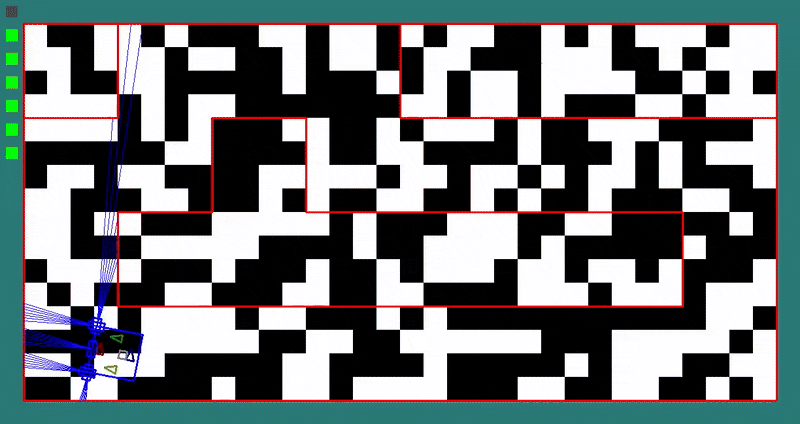

In [ ]:
from IPython.display import Image
Image(open('/content/2025-03-3021-43-24-ezgif.com-optimize.gif','rb').read())

#Note: video is sped up for the sake of reducing filesize

# Simulator

We are using a mobile robot simulator called [simmer-python](https://github.com/UToronto-MIE444/simmer-python) that was developed as a teaching tool for MIE444 Mechatronics Principles at the University of Toronto. The simulator is open-source and was developed for educational purposes.

Note: WE RECOMMEND RUNNING THIS DEMO LOCALLY.  
The pygame simulation will not open in Google Colab.

In [10]:
# We recommend running this demo locally because the pygame simulation will not show up using colab
use_colab=False 

if use_colab:
    %cd /content
    !rm -rf MIE1517-Team25
    !git clone https://github.com/mikanogami/MIE1517-Team25
    %cd MIE1517-Team25

import numpy as np
import pygame
import sys, os
import csv
import datetime, time
import torch
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


sys.path.append(os.path.abspath("simmer-python"))
from maze import Maze
from robot import Robot
from block import Block
from interface.hud import Hud
from interface.communication import TCPServer
import config as CONFIG
import utilities
import main
import simmer

from expert import Expert
from net import RobotControlNet

You can run the mobile robot simulation (using below command) and teleoperate the robot using the following keypress commands:
W/S: move forward/backward  
Q/E: move right/left  
D/A: rotate right/left  

In [4]:
!python simmer-python/simmer.py

pygame 2.6.1 (SDL 2.28.4, Python 3.12.8)
Hello from the pygame community. https://www.pygame.org/contribute.html
SimMeR Loading...
2025-04-06 17:31:04.762 python[38003:46292622] +[IMKClient subclass]: chose IMKClient_Modern
2025-04-06 17:31:04.762 python[38003:46292622] +[IMKInputSession subclass]: chose IMKInputSession_Modern
Execution finished. Closing SimMeR.


simmer-python/config.py file determines the properties of the mobile robot, its sensors, and the maze. We can change the configuration of the robot and the maze by updating the **CONFIG** object from within config.py.

CONFIG.walls: defines the configuration for maze walls  
CONFIG.sensors: defines all sensor types, placements, and errors  

# Data Collection

**Setup Training Environment** *simmer-python/config.py*

First, set up a simple track that we will deploy the robot on to collect training data. The training environment we chose was a rectangular track. We chose a simple training environment because we needed to define a trajectory for the **EXPERT** to collect robot data in that training environment. The pre-defined reference trajectory for this environment is a straight path in the middle of the maze corridor for the straight sections of the track and a circular trajectory with a turning radius of one-half the width of the maze corridor around the corners. The reference trajectory for our training environment is show in the images below in red for both the clockwise and counterclockwise cases.

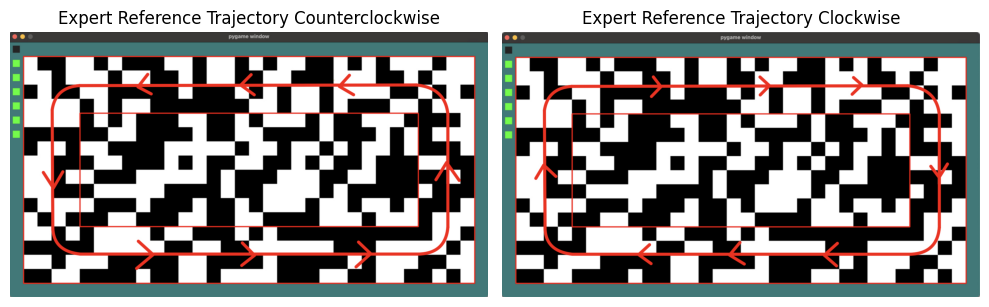

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# First image
img1 = mpimg.imread('notebook/expert_trajectory_CCW.jpeg')
axes[0].imshow(img1)
axes[0].set_title("Expert Reference Trajectory Counterclockwise")
axes[0].axis('off')  # Hide axes

# Second image
img2 = mpimg.imread('notebook/expert_trajectory_CW.jpeg')
axes[1].imshow(img2)
axes[1].set_title("Expert Reference Trajectory Clockwise")
axes[1].axis('off')

plt.tight_layout()
plt.show()

The maze object defined in *simmer-python/config.py* that corresponds to our training environment is:

walls = [[0,0,0,0,0,0,0,0],
         [0,1,1,1,1,1,1,0],
         [0,1,1,1,1,1,1,0],
         [0,0,0,0,0,0,0,0]]

**Creating the Expert** *expert.py*

In imitation learning, the agent (our model) learns to perform a task from expert demonstrations. For the simulated mobile robot, an example of an expert is a human operator, steering the robot using keypresses. We chose to implement the **EXPERT** as a controller that uses PID control to keep the robot moving along a set trajectory. The reference trajectory is straight and in the middle of


**Initial Dataset Collection**
The expert controls the robot as it navigates the training environment. At each timestep, we record the ultrasonic sensor readings (model inputs) and the corresponding steering command from the expert (labels used for supervised learning).

###**Set up Sensors** *simmer-python/config.py*

Define the sensors to be used by the robot. Our model used 5 ultrasonic sensors - with 2 of them rotated 90 degrees clockwise and counterclockwise to capture data from the side.


In [ ]:
import pygame.math as pm

u0_info = {
    'id': 'u0',
    'position': [3, 3],
    'height': 2,
    'rotation': 0,
    'error': 0.02,
    'outline': [
        pm.Vector2(-1, -0.5),
        pm.Vector2(-1, 0.5),
        pm.Vector2(1, 0.5),
        pm.Vector2(1, -0.5)
    ],
    'visible': True,
    'visible_measurement': True
}

Add the sensor definitions to the list of sensors and the simulate list

In [ ]:
(insert sensor list and simulate_list)

###**Robot Movement Definition** *simmer-python/robot.py*

Create a new function to move the robot at a constant speed and accept steering angle inputs.

In [ ]:
Insert move_constant_speed

###**Set Up Main File** *main.py*

Instantiate the expert and its respective PID controllers for track and trajectory.

In [ ]:
Insert code

Within the *while running* loop, similate the sensors.

Obtain errors from the expert and calculate the track and trajectory steering angle adjustment. The total adjustment is the sum of both. Smooth the total adjustment with. variable factor named alpha, to blend the previous and current update.


Collect sensor data and save it to a csv.

###**Main Loop** *main.py*

Set up the robot's starting position and orientation for the clockwise direction. Simulate the robot going in this direction.

Set up the robot's starting position and orientation for the clockwise direction. Simulate the robot going in this direction


###**Tune PID and Alpha** *main.py*

Play around with the K values for the PID controllers and the alpha value for blending the steering adjustment updates such that the expert can drive the robot around the track smoothly and it will not get stuck in the walls. These values may need to be modified as you perform the DAgger and the robot experiences different pertubations that the expert needs to correct.

###**Collect Data** *main.py*

Simply run the main file to collect sensor data. There will be 2 csv's in the data folder, one for the clockwise direction and one for the counterclockwise direction.



# Model Architecture

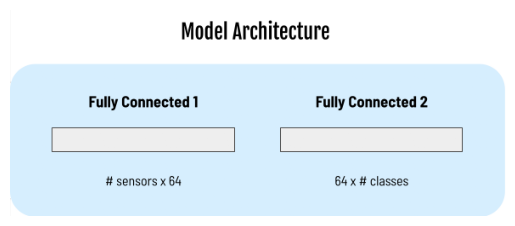

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('Model Architecture.png')  # path to your image
plt.imshow(img)
plt.axis('off')  # hide axis
plt.show()

**Model Definition**

Our chosen model is quite simple, with just 2 fully connected layers. The input size was tested and varied with the number of ultrasonic sensors, while the output size could also change depending on the number of classes chosen. These classes correspond to the discrete bins for steering angle adjustment.


In [ ]:
class RobotControlNet(nn.Module):
  pass

# DAgger Implementation

DAgger, short for Dataset Aggregation, is a common imitation learning algorithm. The model is trained iteratively on data collected from the expert, which controls the robot initially around the track. With this data, the first model is created and then deployed such that it becomes the agent to drive the robot around the track. When the robot veers too far off the desired trajectory, the expert corrects the robot and the data from the expert correcting the robot gets appended to the existing training data. This aggregated training data with more information is then used to train another iteration of the model. This process repeats until the robot is sufficient to drive without the expert taking over.

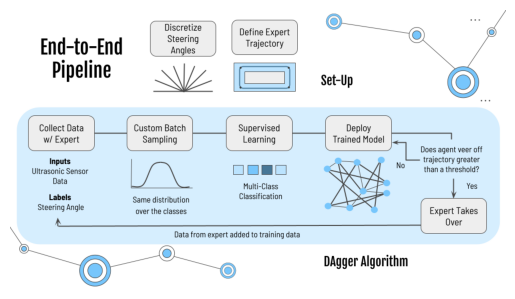

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('End_to_end_pipeline.png')  # path to your image
plt.imshow(img)
plt.axis('off')  # hide axis
plt.show()

###**Create Dataset** *dataloader.py*

Make a custom class for the dataset to read the csv files and extract the desired features.

In [ ]:
class SensorDataset(Dataset):
  pass

###**Pre-Processing** *net.py*
Create a uniform batch sampler that goes over all the data to make sure each batch loaded during training has approximately the same distribution over the classes.

In [ ]:
class UniformBatchSampler(Sampler):
  pass

###**Dataset Visualization** */data/*
Below we can see what the training data looks like after it was collected by the expert. The first 5 columns are the ultrasonic sensor data and the last column is the steering adjustment that the expert outputs. The sensor data constitutes the inputs to our model, while the steering adjustment denotes the labels.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

column_names = ['u0', 'u1', 'u2', 'u3', 'u4', 'steering_adj']
data = pd.read_csv('/content/training_data_0_CW.csv', header=None, names=column_names)
print(data)

             u0         u1         u2         u3        u4  steering_adj
0     26.998100   8.926086   9.085044   8.850926  2.982503      0.000000
1      3.105655  27.127313  32.172367  32.677440  3.020210      0.000000
2      2.956456  27.589206  33.191844  34.176116  3.100854      0.000000
3      3.201267  26.713429  33.170147  29.700889  2.970048      0.000000
4      2.989529  26.510399  35.196852  31.341953  2.838198      0.000000
...         ...        ...        ...        ...       ...           ...
6968   2.841670  25.179740  24.950551  25.306542  3.067135      0.000960
6969   2.755563  26.231458  24.800097  25.814703  3.198268      0.019822
6970   2.908813  22.656311  27.939134  25.820207  2.886324      0.031891
6971   3.128264  25.068710  25.074601  25.896822  3.179017      0.034828
6972   3.059808  24.600401  24.543931  24.963939  3.099389      0.028719

[6973 rows x 6 columns]


From the histogram below, it is clear to see that the robot has a lot more data corrosponding to the smaller steering adjustments, likely due to the greater duration of time spent travelling straight.

In [ ]:
# Insert histogram of data distribution

###**Train Policy** *train_policy.py*
To train the the model, the code is very similar to other models we have trained in class. The only deviation from the normal code is when we weight the errors according to the inverse frequency of occurance. This prevents the model from overfitting to data that is unequally distributed across classes.

In [ ]:
def train_model(model, train_loader, dagger_itr, learning_rate=1e-3, num_epochs=100):

###**Deploy Model** *main.py*
Add logic to toggle between using the model to adjust the steering angle and the expert depending on if the either the cross track error or the heading error is greater than threshold deviation than desired. If the expert corrects the robot's movement, append those lines of the sensor data to the training dataset.

###**Observe Result**
After deploying the model, watch the robot go around the track.

In [ ]:
# Video of model driving track-

###**Repeat Process**
Keep re-training the model with more iterations until you are happy with the result.

# Results on Training Environment

###**Quantitative Results**

###**Qualitative Results**

# Results on Unseen Environment

```
Code to implement on new data
```

###**Quantitative Results**

###**Qualitative Results**

## Summary of Related Work

include citations/references
Results on caomparable projects, links to publications etc

# Discussion

**Is our model performing well? why or why not?**
- yes, the model can navigate a maze it was not trained on
- compared to expert that needs direct trajectory definition - can generalize to other maze shapes

**What is unusual, suprisign or interesting about your results? what did you learn**

**Any great insights from working on this project?**
- PID tuning was pain

## Limitations of our Method

Our method does great on unseen environments consisting of right and left turns because our simple training environment track consisted of only right and left turns. However, the robot struggles in environments containing branching or dead ends.